# 06 -- Genotype x Environment interaction
Follows directly from `05`'s confound check. Re-reading that result
(`Pearson r(genetic_value, environment_value) = 0.230`): there's no real
causal channel from genotype to environment or back within a single trial
season -- a hybrid's genetics don't change which field it's planted in, and
the environment doesn't change a hybrid's DNA (multi-generation selection
or epigenetics could in principle create such a channel, but we have no
data for either and aren't chasing it here). So that correlation is two
model *predictions* agreeing with each other, not evidence of a
genotype-environment relationship -- worth having flagged, not worth
over-interpreting.

**The causally meaningful question is different: does genotype's effect on
phenotype depend on environment, and vice versa?** Two hybrids with
different genetics might respond to the same environmental improvement
differently -- one barely moves, another jumps a lot, maybe some even swap
rank order. That's classical genotype-by-environment (G x E) interaction, a
reaction-norm question, not a genotype-environment-relationship question.
This notebook checks for it two ways:

**Part A -- model-free reaction-norm check.** Look directly at the raw
Hybrid x Env cells before fitting anything: for hybrids tested across a
wide spread of environments, does phenotype respond to environment the same
way for every hybrid, or do the lines have different slopes / cross over?
Mirror version for environments tested across a wide spread of genetics.
**Uses 2014-2023 training cells only** -- this is a diagnostic on the
training distribution, not a holdout evaluation, so the 2024 test cells
stay untouched until Part B.

**Part B -- graduated model comparison.** Three formulas, built
regardless of what Part A shows (Part A informs interpretation of these
results, not whether they get built -- the nonlinear model is a strictly
more general form than the other two either way): (1) the additive
baseline from `05`, (2) additive plus one explicit interaction term, (3) a
small 2-input MLP that can learn a full nonlinear surface. All three
evaluated on training data **and** the true 2024 holdout, side by side, per
project convention.

**Inherited caveat, unchanged from `05`:** `genetic_value` and
`environment_value` here are still `05`'s in-sample, final-model
predictions, not out-of-fold. Everything in this notebook is a first look
under that same caveat -- see `05`'s intro for why, and `NEXT_SESSION.md`
for the OOF rebuild plan this still depends on before any of it is final.

## Setup
Reuses `05`'s saved cell-mean tables directly (`train_cell_means_with_votes.csv`,
`test_cell_means_with_votes.csv`) rather than refitting GBLUP/env_mlp_l2
again -- this notebook is purely about the *relationship* between the two
already-computed votes and phenotype, not about re-deriving the votes
themselves.

In [ ]:
import os
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/g2f_effect_decomposition')
else:
    BASE_PATH = Path(os.environ.get('G2F_BASE_PATH', '.')).resolve()

sys.path.insert(0, str(BASE_PATH))

REL_RESULTS_DIR = BASE_PATH / 'results' / 'effect_relationships'
RESULTS_DIR = BASE_PATH / 'results' / 'gxe_interaction'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"IN_COLAB: {IN_COLAB}")
print(f"BASE_PATH: {BASE_PATH}")

In [ ]:
import torch

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device (training only):', DEVICE)

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
from sklearn.linear_model import LinearRegression

from scripts.relationship_models import (
    vector_feature_mean_std, GxEInteractionMLP, scalar_l2_penalty,
)
from scripts.training import reliability_weights, make_loader, fit_mlp_adam
from scripts.evaluation import evaluate_predictions

pd.set_option('display.max_columns', 50)
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Part B relationship-model hyperparameters -- same REL_* values 05 used for
# its scalar cross-prediction MLPs, since this is the same class of small
# diagnostic model, just with 2 inputs instead of 1.
REL_HIDDEN = 8
REL_L2_LAMBDA = 1e-4
REL_BATCH_SIZE = 256
REL_NUM_EPOCHS = 150
REL_PATIENCE = 15
REL_ADAM_LR = 1e-4

# Part A slope-fitting thresholds -- deliberately printed and checked
# against the actual coverage distribution below before being trusted;
# adjust if too few/many hybrids or environments qualify for this dataset.
MIN_ENVS_PER_HYBRID_FOR_SLOPE = 8
MIN_HYBRIDS_PER_ENV_FOR_SLOPE = 15
TOP_K_FOR_PLOTTING = 12

In [6]:
cell_means = pd.read_csv(REL_RESULTS_DIR / 'train_cell_means_with_votes.csv')
test_cell_means = pd.read_csv(REL_RESULTS_DIR / 'test_cell_means_with_votes.csv')

cell_weights = reliability_weights(cell_means['n_plot_records'].to_numpy())
test_cell_weights = reliability_weights(test_cell_means['n_plot_records'].to_numpy())

print(f"Train cells: {len(cell_means)} ({cell_means['Hybrid'].nunique()} hybrids x "
      f"{cell_means['Env'].nunique()} envs)")
print(f"Test cells:  {len(test_cell_means)} ({test_cell_means['Hybrid'].nunique()} hybrids x "
      f"{test_cell_means['Env'].nunique()} envs)")

Train cells: 106037 (4934 hybrids x 269 envs)
Test cells:  9486 (1063 hybrids x 22 envs)


## Part A -- Model-free reaction-norm check (training cells only)

### A1. Coverage: how many environments does each hybrid have, and how much do those environments' `environment_value`s actually spread out?
A hybrid tested in many environments that all happen to score similarly on
`environment_value` isn't useful for this check -- need both count *and*
spread.

In [7]:
hybrid_coverage = (
    cell_means.groupby('Hybrid')
    .agg(n_envs=('Env', 'nunique'),
         ev_range=('environment_value', lambda s: s.max() - s.min()),
         ev_std=('environment_value', 'std'),
         mean_genetic_value=('genetic_value', 'mean'))
    .reset_index()
)
print("Environments tested per hybrid -- distribution:")
print(hybrid_coverage['n_envs'].describe())

Environments tested per hybrid -- distribution:
count    4934.000000
mean       21.491082
std        19.317029
min         1.000000
25%        10.000000
50%        17.000000
75%        29.000000
max       256.000000
Name: n_envs, dtype: float64


In [8]:
hybrid_slope_candidates = hybrid_coverage[hybrid_coverage['n_envs'] >= MIN_ENVS_PER_HYBRID_FOR_SLOPE]
print(f"Hybrids clearing >= {MIN_ENVS_PER_HYBRID_FOR_SLOPE} environments: "
      f"{len(hybrid_slope_candidates)} / {len(hybrid_coverage)}")

hybrid_plot_selection = hybrid_slope_candidates.nlargest(TOP_K_FOR_PLOTTING, 'ev_range')['Hybrid'].tolist()
print(f"Selected for plotting (widest environment_value spread among qualifying hybrids): "
      f"{len(hybrid_plot_selection)} hybrids")

Hybrids clearing >= 8 environments: 4092 / 4934
Selected for plotting (widest environment_value spread among qualifying hybrids): 12 hybrids


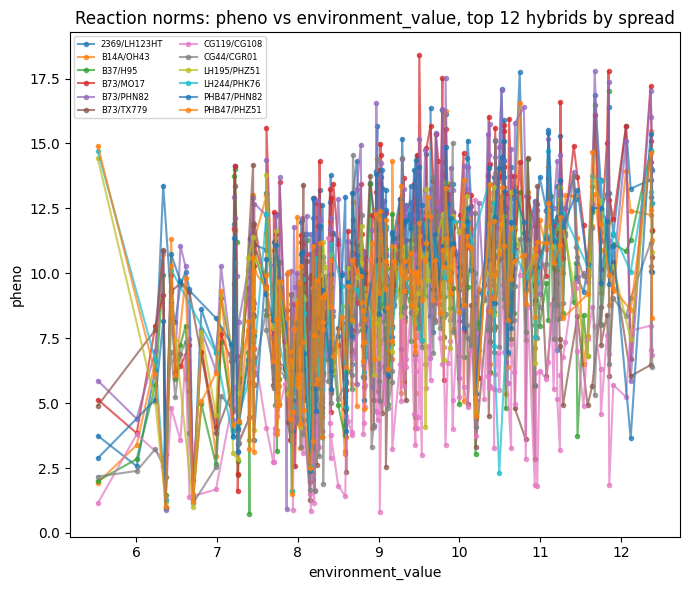

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))
for hybrid in hybrid_plot_selection:
    sub = cell_means[cell_means['Hybrid'] == hybrid].sort_values('environment_value')
    ax.plot(sub['environment_value'], sub['pheno'], marker='o', markersize=3, alpha=0.7, label=hybrid)
ax.set_xlabel('environment_value')
ax.set_ylabel('pheno')
ax.set_title(f'Reaction norms: pheno vs environment_value, top {len(hybrid_plot_selection)} hybrids by spread')
ax.legend(fontsize=6, ncol=2, loc='best')
plt.tight_layout()
plt.show()

### A2. Mirror: how many hybrids does each environment test, and how much does *their* `genetic_value` spread out?
Environments should clear a high hybrid-count bar more easily than hybrids
clear an environment-count bar, given far more hybrids (~thousands) than
environments (~hundreds) in this dataset.

In [10]:
env_coverage = (
    cell_means.groupby('Env')
    .agg(n_hybrids=('Hybrid', 'nunique'),
         gv_range=('genetic_value', lambda s: s.max() - s.min()),
         gv_std=('genetic_value', 'std'),
         mean_environment_value=('environment_value', 'mean'))
    .reset_index()
)
print("Hybrids tested per environment -- distribution:")
print(env_coverage['n_hybrids'].describe())

Hybrids tested per environment -- distribution:
count     269.000000
mean      394.189591
std       203.846860
min        22.000000
25%       247.000000
50%       399.000000
75%       443.000000
max      1149.000000
Name: n_hybrids, dtype: float64


In [11]:
env_slope_candidates = env_coverage[env_coverage['n_hybrids'] >= MIN_HYBRIDS_PER_ENV_FOR_SLOPE]
print(f"Environments clearing >= {MIN_HYBRIDS_PER_ENV_FOR_SLOPE} hybrids: "
      f"{len(env_slope_candidates)} / {len(env_coverage)}")

env_plot_selection = env_slope_candidates.nlargest(TOP_K_FOR_PLOTTING, 'gv_range')['Env'].tolist()
print(f"Selected for plotting (widest genetic_value spread among qualifying environments): "
      f"{len(env_plot_selection)} environments")

Environments clearing >= 15 hybrids: 269 / 269
Selected for plotting (widest genetic_value spread among qualifying environments): 12 environments


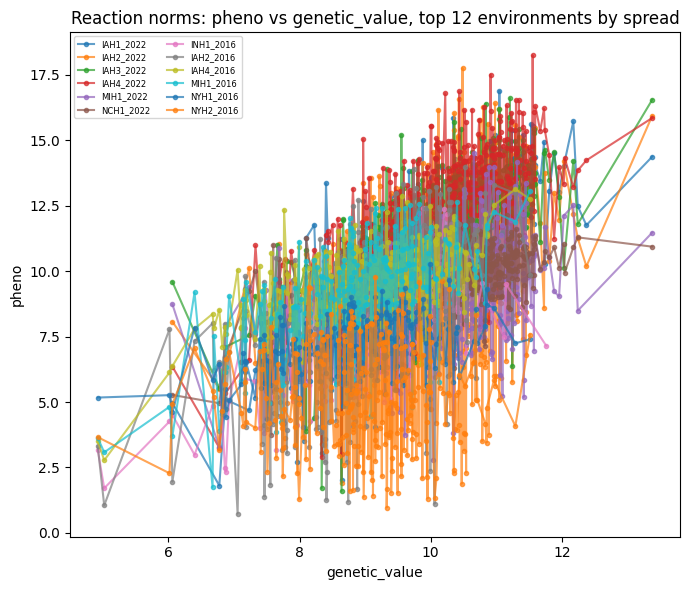

In [12]:
fig, ax = plt.subplots(figsize=(7, 6))
for env in env_plot_selection:
    sub = cell_means[cell_means['Env'] == env].sort_values('genetic_value')
    ax.plot(sub['genetic_value'], sub['pheno'], marker='o', markersize=3, alpha=0.7, label=env)
ax.set_xlabel('genetic_value')
ax.set_ylabel('pheno')
ax.set_title(f'Reaction norms: pheno vs genetic_value, top {len(env_plot_selection)} environments by spread')
ax.legend(fontsize=6, ncol=2, loc='best')
plt.tight_layout()
plt.show()

### A3. Quantify: per-hybrid and per-environment slopes
Fit a simple `pheno ~ x` slope within each qualifying hybrid's own cells
(`x = environment_value`) and within each qualifying environment's own
cells (`x = genetic_value`). Uses the full qualifying set from A1/A2, not
just the smaller top-K plotted above, since the slope *distribution* is
more informative with more hybrids/environments in it than a legible plot
can show at once.

Wide variance in these slopes is the quantitative version of "the lines in
the plots above have different steepness." Crossing lines specifically
(some hybrids with a positive slope, others negative) is the strongest
single signal of real G x E interaction, stronger than variance alone.

In [13]:
def fit_slopes(df: pd.DataFrame, group_col: str, x_col: str, candidates: pd.Series) -> pd.DataFrame:
    rows = []
    for group_id in candidates:
        sub = df[df[group_col] == group_id]
        if sub[x_col].nunique() < 2:
            continue
        result = linregress(sub[x_col], sub['pheno'])
        rows.append({group_col: group_id, 'slope': result.slope, 'intercept': result.intercept,
                     'r_value': result.rvalue, 'n_cells': len(sub)})
    return pd.DataFrame(rows)


hybrid_slopes = fit_slopes(cell_means, 'Hybrid', 'environment_value', hybrid_slope_candidates['Hybrid'])
env_slopes = fit_slopes(cell_means, 'Env', 'genetic_value', env_slope_candidates['Env'])

print(f"Per-hybrid slope of pheno ~ environment_value ({len(hybrid_slopes)} hybrids):")
print(hybrid_slopes['slope'].describe())
print(f"\nFraction with a negative slope (phenotype falling as environment improves): "
      f"{(hybrid_slopes['slope'] < 0).mean():.1%}")

print(f"\nPer-environment slope of pheno ~ genetic_value ({len(env_slopes)} environments):")
print(env_slopes['slope'].describe())
print(f"\nFraction with a negative slope (phenotype falling as genetics improve): "
      f"{(env_slopes['slope'] < 0).mean():.1%}")

Per-hybrid slope of pheno ~ environment_value (4092 hybrids):
count    4092.000000
mean        1.063630
std         0.614671
min        -3.740512
25%         0.709205
50%         1.038324
75%         1.403029
max         4.854994
Name: slope, dtype: float64

Fraction with a negative slope (phenotype falling as environment improves): 3.0%

Per-environment slope of pheno ~ genetic_value (269 environments):
count    269.000000
mean       0.826634
std        0.410244
min       -0.384248
25%        0.550343
50%        0.798008
75%        1.143043
max        1.883917
Name: slope, dtype: float64

Fraction with a negative slope (phenotype falling as genetics improve): 1.1%


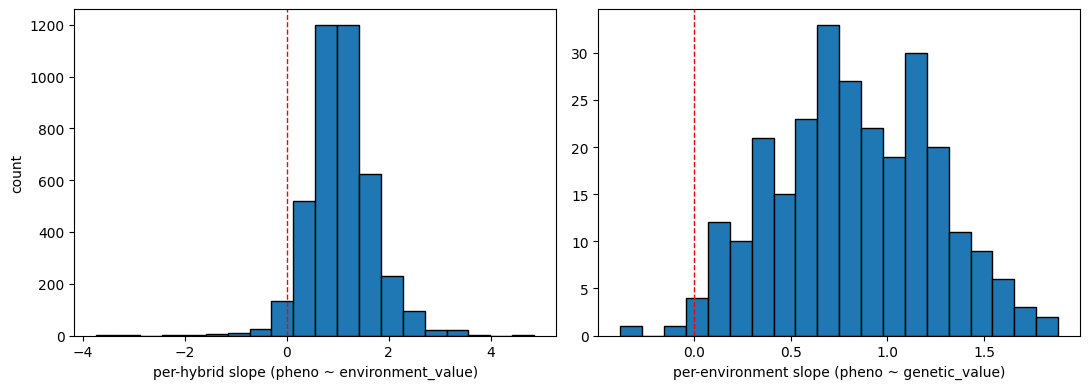

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(hybrid_slopes['slope'], bins=20, edgecolor='black')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('per-hybrid slope (pheno ~ environment_value)')
axes[0].set_ylabel('count')
axes[1].hist(env_slopes['slope'], bins=20, edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('per-environment slope (pheno ~ genetic_value)')
plt.tight_layout()
plt.show()

In [15]:
hybrid_slopes_with_gv = hybrid_slopes.merge(
    hybrid_coverage[['Hybrid', 'mean_genetic_value']], on='Hybrid')
slope_vs_gv_r = evaluate_predictions(
    hybrid_slopes_with_gv['mean_genetic_value'], hybrid_slopes_with_gv['slope'])['pearson_r']
print(f"Correlation between a hybrid's environmental-response slope and its own genetic_value: "
      f"{slope_vs_gv_r:.3f}")
print("  positive -> already-strong hybrids respond MORE to a better environment (fan-out)")
print("  negative -> already-strong hybrids respond LESS (compression / crossover-prone)")
print("  ~0       -> response to environment doesn't depend on genetic strength")

env_slopes_with_ev = env_slopes.merge(
    env_coverage[['Env', 'mean_environment_value']], on='Env')
slope_vs_ev_r = evaluate_predictions(
    env_slopes_with_ev['mean_environment_value'], env_slopes_with_ev['slope'])['pearson_r']
print(f"\nCorrelation between an environment's genetic-response slope and its own environment_value: "
      f"{slope_vs_ev_r:.3f}")
print("  positive -> better environments amplify genetic differences (fan-out)")
print("  negative -> better environments compress genetic differences")
print("  ~0       -> genetic differences show up the same regardless of environment quality")

Correlation between a hybrid's environmental-response slope and its own genetic_value: -0.070
  positive -> already-strong hybrids respond MORE to a better environment (fan-out)
  negative -> already-strong hybrids respond LESS (compression / crossover-prone)
  ~0       -> response to environment doesn't depend on genetic strength

Correlation between an environment's genetic-response slope and its own environment_value: 0.379
  positive -> better environments amplify genetic differences (fan-out)
  negative -> better environments compress genetic differences
  ~0       -> genetic differences show up the same regardless of environment quality


### Part A summary
Fill in after running:
- Do the reaction-norm plots show roughly parallel lines, or visibly
  different slopes / crossovers?
- What fraction of hybrids have a negative environmental-response slope
  (worth knowing on its own, separate from interaction) -- and does that
  fraction look like noise around a mostly-positive population, or a real
  mixed pattern?
- Does slope correlate with genetic_value / environment_value (fan-out vs
  compression vs no relationship)?
- Net read: does Part A look like real G x E interaction, or close to
  additive? (Part B gets built either way -- see below -- but this sets
  the expectation for what Part B should find.)

## Part B -- Graduated model comparison
Three formulas, evaluated identically on training cells (in-sample) and the
true 2024 holdout. `genetic_value`/`environment_value` are standardized
(train-only mean/std) wherever they feed a product term or the MLP, so
coefficients and comparisons aren't distorted by the two votes living on
different natural scales; the additive baseline stays on raw (yield-scale)
inputs, matching `05`, so its coefficients stay directly interpretable.

In [16]:
gv_ev_mean, gv_ev_std = vector_feature_mean_std(
    cell_means[['genetic_value', 'environment_value']].to_numpy())

def standardize(df: pd.DataFrame) -> np.ndarray:
    raw = df[['genetic_value', 'environment_value']].to_numpy()
    return (raw - gv_ev_mean) / gv_ev_std

X_train_std = standardize(cell_means)
X_test_std = standardize(test_cell_means)
y_train = cell_means['pheno'].to_numpy()
y_test = test_cell_means['pheno'].to_numpy()

### B1. Additive baseline
`pheno ~ a*genetic_value + b*environment_value + bias`, raw scale --
identical formula to `05`'s baseline fusion, refit here for a
self-contained comparison table.

In [17]:
X_train_raw = cell_means[['genetic_value', 'environment_value']].to_numpy()
X_test_raw = test_cell_means[['genetic_value', 'environment_value']].to_numpy()

additive_reg = LinearRegression().fit(X_train_raw, y_train, sample_weight=cell_weights)
additive_train_pred = additive_reg.predict(X_train_raw)
additive_test_pred = additive_reg.predict(X_test_raw)

print(f"additive: a={additive_reg.coef_[0]:.3f}, b={additive_reg.coef_[1]:.3f}, "
      f"bias={additive_reg.intercept_:.3f}")

additive: a=0.729, b=0.945, bias=-6.375


### B2. Additive + explicit interaction term
Adds `c * genetic_value_std * environment_value_std` on top of the same
two main effects, all three on the standardized scale -- an unstandardized
product term can look spuriously significant purely from scale, so this
keeps `c` comparable to `a`/`b`.

In [18]:
def add_interaction_col(X_std: np.ndarray) -> np.ndarray:
    interaction = (X_std[:, 0] * X_std[:, 1]).reshape(-1, 1)
    return np.hstack([X_std, interaction])

X_train_interaction = add_interaction_col(X_train_std)
X_test_interaction = add_interaction_col(X_test_std)

interaction_reg = LinearRegression().fit(X_train_interaction, y_train, sample_weight=cell_weights)
interaction_train_pred = interaction_reg.predict(X_train_interaction)
interaction_test_pred = interaction_reg.predict(X_test_interaction)

a_std, b_std, c_std = interaction_reg.coef_
print(f"interaction (standardized inputs): a={a_std:.3f}, b={b_std:.3f}, c(interaction)={c_std:.3f}, "
      f"bias={interaction_reg.intercept_:.3f}")
print("  c far from 0 and improving holdout fit below -> real interaction beyond the additive baseline")
print("  c near 0 -> consistent with an additive relationship (check against Part A's slope plots)")

interaction (standardized inputs): a=0.763, b=1.345, c(interaction)=0.133, bias=9.643
  c far from 0 and improving holdout fit below -> real interaction beyond the additive baseline
  c near 0 -> consistent with an additive relationship (check against Part A's slope plots)


### B3. Full nonlinear surface -- 2-input MLP
`GxEInteractionMLP`: same small single-hidden-layer architecture as `05`'s
scalar relationship models, just with both standardized votes as input
instead of one. Built regardless of B2's result -- a strictly more general
form than either the additive or single-interaction-term formula, so it
either confirms them (by not beating them) or catches a shape a single
product term can't express.

In [19]:
gxe_model = GxEInteractionMLP(hidden_dim=REL_HIDDEN)
train_loader = make_loader(X_train_std.astype(np.float32), y_train.astype(np.float32),
                            cell_weights, REL_BATCH_SIZE, shuffle=True)
penalty_fn = lambda m: scalar_l2_penalty(m, REL_L2_LAMBDA)
gxe_model, _ = fit_mlp_adam(gxe_model, train_loader, train_loader, penalty_fn, REL_ADAM_LR,
                             REL_NUM_EPOCHS, REL_PATIENCE, DEVICE, verbose=False)

gxe_model.eval()
with torch.no_grad():
    gxe_train_pred = gxe_model(torch.as_tensor(X_train_std, dtype=torch.float32).to(DEVICE)).cpu().numpy()
    gxe_test_pred = gxe_model(torch.as_tensor(X_test_std, dtype=torch.float32).to(DEVICE)).cpu().numpy()

print(f"2-input MLP: train pearson_r={evaluate_predictions(y_train, gxe_train_pred)['pearson_r']:.3f}")

2-input MLP: train pearson_r=0.584


### B4. Comparison table -- train and true 2024 holdout, side by side
Includes genotype-alone and environment-alone as reference points (from
`05`), same convention as `05`'s final comparison -- fusion only matters if
it beats the stronger single effect, not just the weaker one.

In [20]:
def comparison_row(formula, y_true_train, pred_train, y_true_test, pred_test, coefs=None):
    row = {'formula': formula}
    train_metrics = evaluate_predictions(y_true_train, pred_train)
    test_metrics = evaluate_predictions(y_true_test, pred_test)
    row['train_pearson_r'] = train_metrics['pearson_r']
    row['train_rmse'] = train_metrics['rmse']
    row['test_pearson_r'] = test_metrics['pearson_r']
    row['test_rmse'] = test_metrics['rmse']
    if coefs:
        row.update(coefs)
    return row


gxe_comparison = pd.DataFrame([
    comparison_row('genetic_value alone', y_train, cell_means['genetic_value'],
                    y_test, test_cell_means['genetic_value']),
    comparison_row('environment_value alone', y_train, cell_means['environment_value'],
                    y_test, test_cell_means['environment_value']),
    comparison_row('additive baseline', y_train, additive_train_pred, y_test, additive_test_pred,
                    coefs={'a': additive_reg.coef_[0], 'b': additive_reg.coef_[1], 'c': np.nan}),
    comparison_row('additive + interaction', y_train, interaction_train_pred, y_test, interaction_test_pred,
                    coefs={'a': a_std, 'b': b_std, 'c': c_std}),
    comparison_row('2-input MLP (nonlinear)', y_train, gxe_train_pred, y_test, gxe_test_pred),
])
gxe_comparison

,formula,train_pearson_r,train_rmse,test_pearson_r,test_rmse,a,b,c
0,genetic_value alone,0.352216,2.800947,0.116366,3.031744,NaN,NaN,NaN
1,environment_value alone,0.514323,2.568837,0.261467,2.948522,NaN,NaN,NaN
2,additive baseline,0.567665,2.457379,0.284340,3.098458,0.728637,0.944810,NaN
3,additive + interaction,0.569213,2.454090,0.282740,3.200093,0.763341,1.345062,0.132792
4,2-input MLP (nonlinear),0.584265,2.422576,0.256492,3.145481,NaN,NaN,NaN


## Save results

In [21]:
hybrid_slopes_with_gv.to_csv(RESULTS_DIR / 'hybrid_reaction_norm_slopes.csv', index=False)
env_slopes_with_ev.to_csv(RESULTS_DIR / 'env_reaction_norm_slopes.csv', index=False)
gxe_comparison.to_csv(RESULTS_DIR / 'gxe_model_comparison.csv', index=False)

print(f"Saved to {RESULTS_DIR}")
print("  hybrid_reaction_norm_slopes.csv -- per-hybrid slope of pheno ~ environment_value + own genetic_value")
print("  env_reaction_norm_slopes.csv    -- per-environment slope of pheno ~ genetic_value + own environment_value")
print("  gxe_model_comparison.csv        -- genotype/environment alone vs all 3 fusion formulas, train + true 2024 holdout")

Saved to /content/drive/MyDrive/g2f_effect_decomposition/results/gxe_interaction
  hybrid_reaction_norm_slopes.csv -- per-hybrid slope of pheno ~ environment_value + own genetic_value
  env_reaction_norm_slopes.csv    -- per-environment slope of pheno ~ genetic_value + own environment_value
  gxe_model_comparison.csv        -- genotype/environment alone vs all 3 fusion formulas, train + true 2024 holdout


## Summary
Fill in after running:
- Part A: parallel lines or real slope variation / crossovers? What did the
  slope-vs-genetic_value and slope-vs-environment_value correlations show
  (fan-out, compression, or no relationship)?
- Part B: does `c` (the interaction coefficient) come out meaningfully
  nonzero, and does it actually improve **test** fit, not just train?
- Does the 2-input MLP beat the additive-plus-interaction formula on test,
  or do the two land in the same place (suggesting the single product term
  already captures what nonlinearity exists)?
- How does the winning fusion formula compare to `environment_value` alone
  on the true holdout -- does *any* fusion approach here beat the stronger
  single effect yet, on both pearson_r and rmse (recall `05`'s baseline
  fusion won on r but lost on rmse -- check whether that pattern persists
  or resolves here)?
- **Still true:** every number above depends on `genetic_value`/
  `environment_value` being in-sample. Rebuilding those as out-of-fold
  predictions (see `NEXT_SESSION.md`) and rerunning this notebook is still
  the thing that would make any of this final.